# SALES PREDICTION USING PYTHON

## About the Dataset

This dataset is used for performing **Sales Prediction** using Python and machine learning techniques.

The dataset contains information about how much money was spent on advertising through various channels — **TV**, **Radio**, and **Newspaper** — and the resulting **Sales** for a product.

### Features:
- **TV**: Budget spent on TV advertisements (in thousands of dollars)
- **Radio**: Budget spent on Radio advertisements (in thousands of dollars)
- **Newspaper**: Budget spent on Newspaper advertisements (in thousands of dollars)
- **Sales**: Sales of the product (in thousands of units)

### Objective:
To predict future **Sales** based on the amount spent on advertising through these channels. This is a typical regression task where businesses aim to optimize their advertising budget to maximize sales.

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Description

In [2]:
df = pd.read_csv('Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## Data Preprocessing

### 1. Drop **Unuseful** columns

In [5]:
df.drop(columns='Unnamed: 0', inplace=True)

### 2. Check **Duplicates**

In [6]:
df.duplicated().sum()

0

### 3. Check **Missing Values**

In [7]:
df.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

### 4. Check Outliers

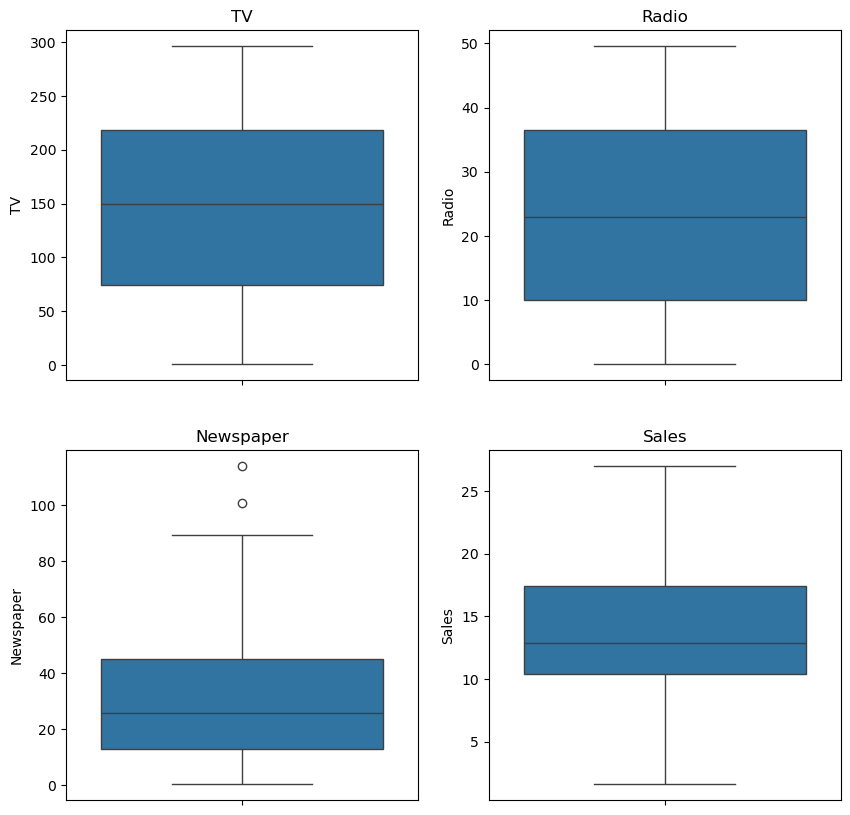

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2 , figsize=(10, 10))
axes = axes.ravel()

for i, col in enumerate(df.columns):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)

#### These show There is **No Significant Outliers**

## Exploratory Data Analysis (EDA)

In [9]:
df.sample(1)

,TV,Radio,Newspaper,Sales
115,75.1,35.0,52.7,12.6


### Sales Distribution

Text(0, 0.5, 'Frequency')

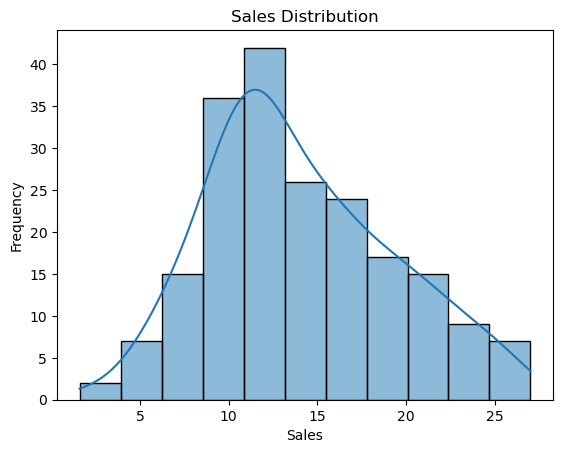

In [10]:
sns.histplot(df['Sales'], kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

### Relationships between all Features.

Text(0.5, 1.0, 'Pairplot of Features')

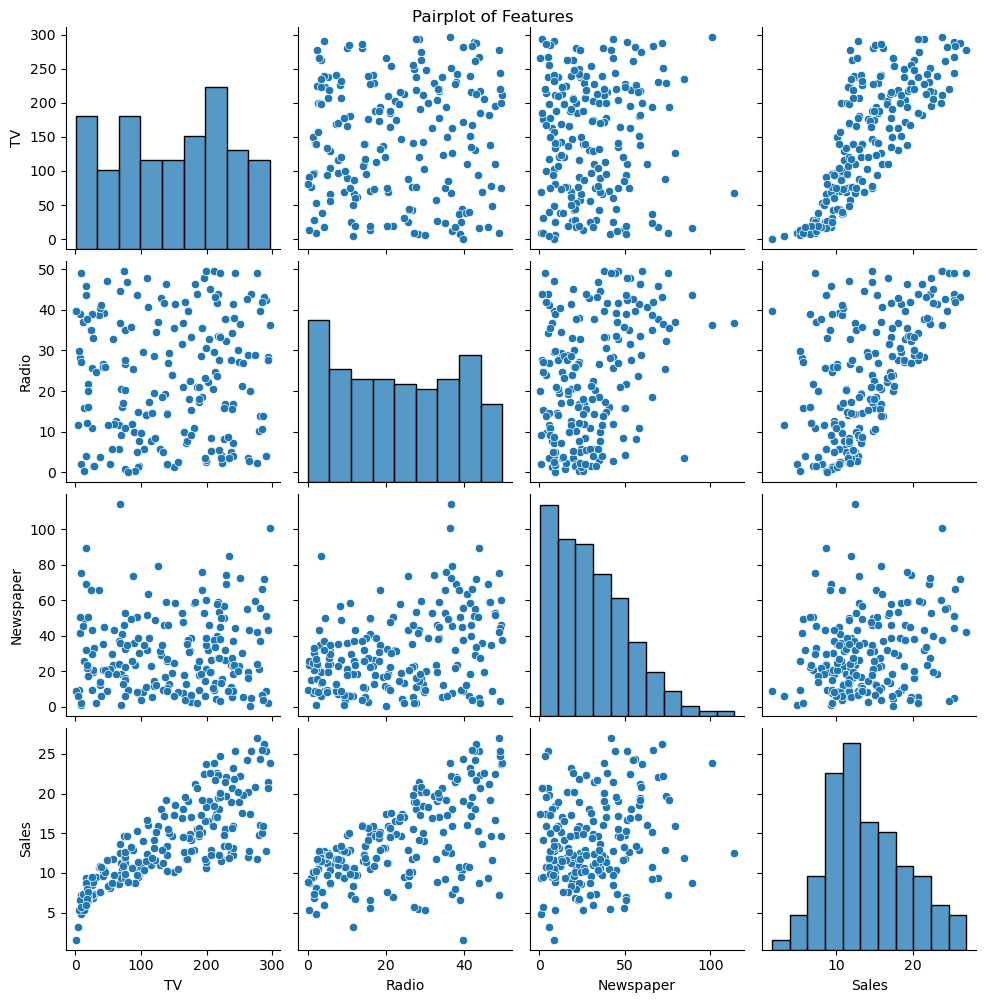

In [11]:
sns.pairplot(df)
plt.suptitle("Pairplot of Features", y=1.0)

### Sales vs. TV Advertising

Text(0, 0.5, 'Sales')

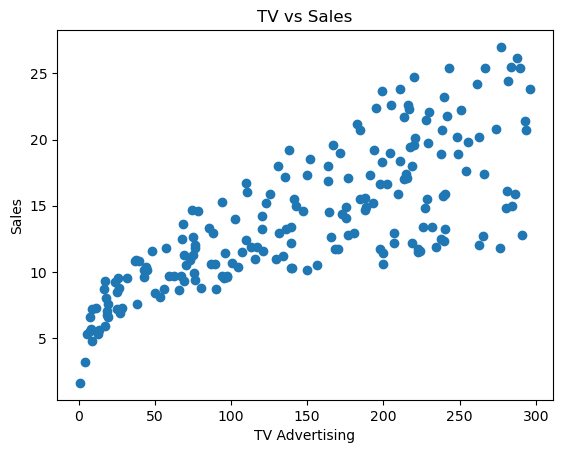

In [12]:
plt.scatter(x=df['TV'], y=df['Sales'])
plt.title("TV vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")

#### This figure show that **TV Advertising** has **Strong Positive** Relasionship with Sales

### Sales vs. Radio Advertising

Text(0, 0.5, 'Sales')

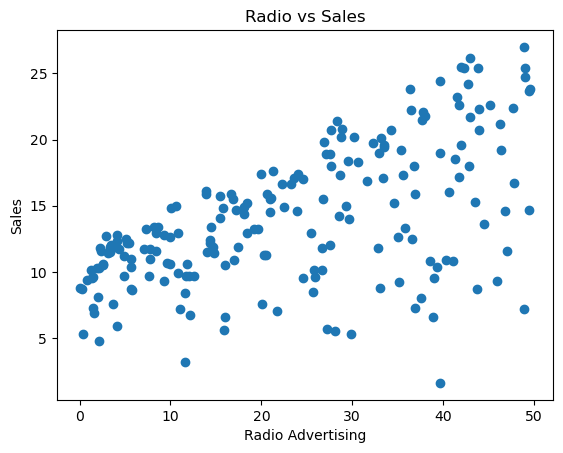

In [13]:
plt.scatter(x=df['Radio'], y=df['Sales'])
plt.title("Radio vs Sales")
plt.xlabel("Radio Advertising")
plt.ylabel("Sales")

#### This figure show that **Radio Advertising** has **Strong Positive** Relasionship with Sales

### Sales vs. Newspaper Advertising

Text(0, 0.5, 'Sales')

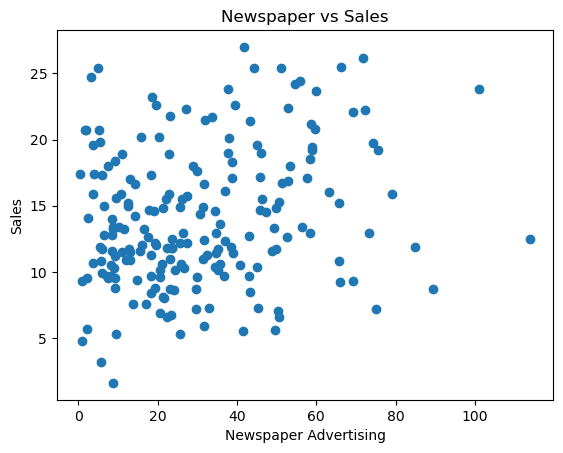

In [14]:
plt.scatter(x=df['Newspaper'], y=df['Sales'])
plt.title("Newspaper vs Sales")
plt.xlabel("Newspaper Advertising")
plt.ylabel("Sales")

#### This figure show that **Newspaper Advertising dosen't have Strong** Relasionship with Sales

### Correlation Matrix

Text(0.5, 1.0, 'Correlation Matrix')

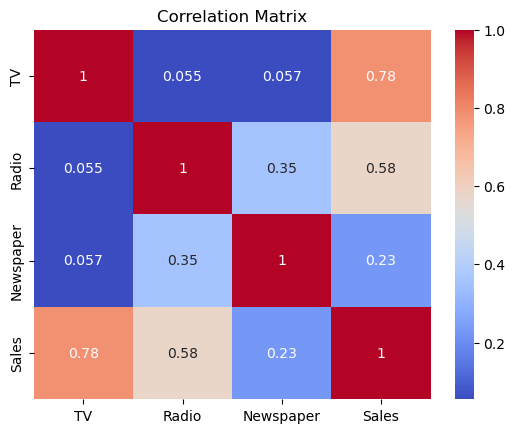

In [15]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

## Feature Engineering

### Feature Selection

#### Since **Newspaper** feature dosen't have strong Relation with our Target **Sales** so, will remove it from **Model Training**

### Data Splitting

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X = df.drop(columns=['Sales','Newspaper'])
y = df['Sales']  # Targrt

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Data Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
SS = StandardScaler()

X_train = SS.fit_transform(X_train)
X_test = SS.transform(X_test)

## Modeling (Linear Regression)

In [21]:
from sklearn.linear_model import LinearRegression

### Training

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Evaluation

In [23]:
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
y_pred = model.predict(X_test)

In [25]:
y_test.head(), y_pred[:5]

(95     16.9
 15     22.4
 30     21.4
 158     7.3
 128    24.7
 Name: Sales, dtype: float64,
 array([16.35747252, 20.86299397, 21.52505848, 10.58719845, 22.22459614]))

In [26]:
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 2))
print("R² Score:", round(r2_score(y_test, y_pred), 2))

Mean Squared Error: 3.14
R² Score: 0.9


#### This means **Linear Regression** model **explains 90%** of the **variance** in the car prices

## Modeling (KNN)

In [27]:
from sklearn.neighbors import KNeighborsRegressor

### Training

In [28]:
model = KNeighborsRegressor()
model.fit(X_train, y_train)

KNeighborsRegressor()

### Evaluation

In [29]:
y_pred = model.predict(X_test)

In [30]:
y_test.head(), y_pred[:5]

(95     16.9
 15     22.4
 30     21.4
 158     7.3
 128    24.7
 Name: Sales, dtype: float64,
 array([16.94, 22.18, 20.68,  6.98, 23.12]))

In [31]:
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 2))
print("R² Score:", round(r2_score(y_test, y_pred), 2))

Mean Squared Error: 1.32
R² Score: 0.96


#### This means **KNN** model **explains 96%** of the **variance** in the car prices

## Modelling (Random Forest)

In [32]:
from sklearn.ensemble import RandomForestRegressor

### Training

In [33]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

### Evaluation

In [34]:
y_pred = model.predict(X_test)

In [35]:
y_test.head(), y_pred[:5]

(95     16.9
 15     22.4
 30     21.4
 158     7.3
 128    24.7
 Name: Sales, dtype: float64,
 array([17.441, 21.98 , 20.506,  6.948, 23.305]))

In [36]:
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 2))
print("R² Score:", round(r2_score(y_test, y_pred), 2))

Mean Squared Error: 0.43
R² Score: 0.99


#### This means **Random Forest** model **explains 99%** of the **variance** in the car prices

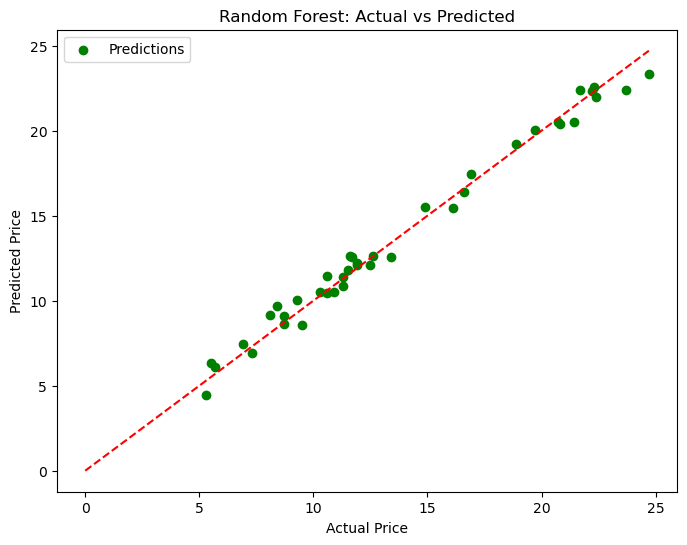

In [37]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='green', label='Predictions')
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted')
plt.legend()

### Make Pipeline
#### Automatically applies preprocessing (like scaling, feature selection) before prediction.

In [38]:
from sklearn.pipeline import Pipeline

In [39]:
# Create pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor())
])

In [40]:
# Fit pipeline
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestRegressor())])

In [41]:
y_pred = pipe.predict(X_test)

In [42]:
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 2))
print("R² Score:", round(r2_score(y_test, y_pred), 2))

Mean Squared Error: 0.39
R² Score: 0.99


### Model & Pipeline Saving

#### Since **Random Forest** is best model, so will save it for Deployment

In [ ]:
import joblib

In [43]:
joblib.dump(model, 'sales_adv_model.pkl')
joblib.dump(pipe, 'sales_adv_pipeline.pkl')

['sales_adv_pipeline.pkl']

### Predection
**TV** = 120.2, **Radio** = 19.6

In [45]:
input_data = np.array([[120.2, 19.6]])
predicted_sales = pipe.predict(input_data)

print(f"Predicted Sales: {predicted_sales[0]:.2f} thousand units")

Predicted Sales: 26.13 thousand units
